In [35]:
# Импорты
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, SelectFromModel, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

In [36]:
# Генерация данных
x_data_generated, y_data_generated = make_classification(scale=1, random_state=RANDOM_STATE)

In [37]:
# Модель логистической регрессии и средняя точность
base_accuracy = cross_val_score(LogisticRegression(), x_data_generated, y_data_generated, scoring='accuracy').mean()
print(f'{base_accuracy:.4f}')

0.9800


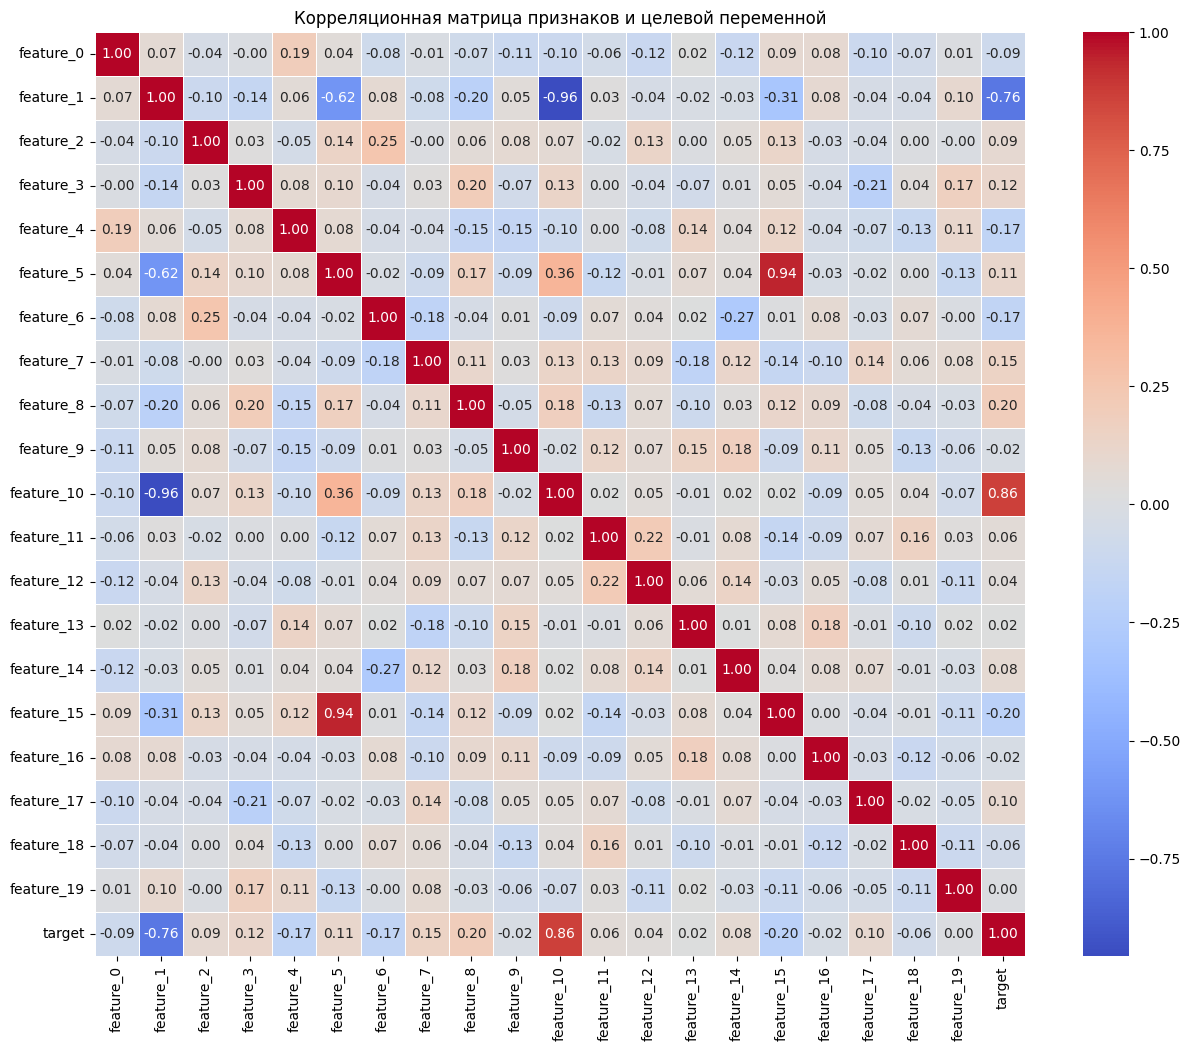

In [38]:
# Корреляционная матрица признаков

df_combined = pd.DataFrame(x_data_generated, columns=[f'feature_{i}' for i in range(x_data_generated.shape[1])])
df_combined['target'] = y_data_generated

correlation_matrix_with_target = df_combined.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix_with_target, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляционная матрица признаков и целевой переменной')
plt.show()

### Выбор признаков на основе матрицы корреляции (обновлено):

*   **оставить (относительно высокая корреляция с целевой переменной > 0.1):**
    *   `feature_1` (-0.76)
    *   `feature_3` (0.12)
    *   `feature_4` (-0.17)
    *   `feature_5` (-0.11)
    *   `feature_6` (-0.17)
    *   `feature_7` (0.15)
    *   `feature_8` (0.20)
    *   `feature_10` (0.86)
    *   `feature_15` (-0.20)
    


*   **Удалить (очень низкая корреляция с целевой переменной):**
    *   `feature_0` (-0.09)
    *   `feature_2` (0.09)
    *   `feature_9` (-0.02)
    *   `feature_11` (0.06)
    *   `feature_12` (0.04)
    *   `feature_13` (0.02)
    *   `feature_14` (0.08)
    *   `feature_16` (-0.02)
    *   `feature_17` (0.10)
    *   `feature_18` (-0.06)
    *   `feature_19` (0.00)


* `feature_10` и `feature_1` очень сильно коррелируют друг с другом .  (удалить `feature_1`**, так как `feature_10` имеет более сильную корреляцию с целевой переменной.)


* `feature_5` и `feature_15` имеют высокую корреляцию между собой.( удалить `feature_5`, так как `feature_15` имеет более сильную корреляцию с целевой переменной.)

Таким образом, предлагаемый набор признаков для сохранения будет: `feature_3`, `feature_4`,`feature_6`,`feature_7`,`feature_8`,`feature_10`, `feature_15`.



In [39]:
# Абсолютные корреляции всех признаков с целевой переменной
correlations_with_target = df_combined.corr()['target'].drop('target').abs()

# Адаптивный порог (среднее абсолютных корреляций) и отбираем начальные признаки
adaptive_threshold = correlations_with_target.mean()

initial_selected_features = correlations_with_target[correlations_with_target > adaptive_threshold].index.tolist()

print(f"Адаптивный порог корреляции с целевой переменной: {adaptive_threshold:.4f}")
print(f"Изначально отобранные признаки (по корреляции с целевой): {initial_selected_features}")
print(f"Количество изначально отобранных признаков: {len(initial_selected_features)}")

# Мультиколлинеарность среди изначально отобранных признаков
subset_df = df_combined[initial_selected_features]
corr_matrix_features = subset_df.corr().abs()

features_to_remove = []
multicollinearity_threshold = 0.8

# Используем initial_selected_features для получения индексов и названий признаков
if len(initial_selected_features) > 1:
    for i in range(len(initial_selected_features)):
        for j in range(i + 1, len(initial_selected_features)):
            f1 = initial_selected_features[i]
            f2 = initial_selected_features[j]

            if f1 in features_to_remove or f2 in features_to_remove:
                continue
            if corr_matrix_features.loc[f1, f2] > multicollinearity_threshold:
                if correlations_with_target[f1] < correlations_with_target[f2]:
                    features_to_remove_due_to_multicollinearity.append(f1)
                    print(f"Удаляем '{f1}' из-за высокой корреляции с '{f2}' (корр. {corr_matrix_features.loc[f1, f2]:.2f}) и меньшей корреляции с целевой переменной")
                else:
                    features_to_remove_due_to_multicollinearity.append(f2)
                    print(f"Удаляем '{f2}' из-за высокой корреляции с '{f1}' (корр. {corr_matrix_features.loc[f1, f2]:.2f}) и меньшей корреляции с целевой переменной")

# Удаляем признаки, отмеченные для удаления из initial_selected_features, чтобы получить final_selected_features
final_selected_features = [f for f in initial_selected_features if f not in features_to_remove_due_to_multicollinearity]

print(f"Финально отобранные признаки (после устранения мультиколлинеарности): {final_selected_features}")
print(f"Количество финально отобранных признаков: {len(final_selected_features)}")

# Обновляем cleaned_data_features и cleaned_data с финально отобранными признаками
selected_features = final_selected_features
cleaned_data_features = df_combined[selected_features]
cleaned_data = df_combined[selected_features + ['target']]

print(f"Итоговое количество признаков в cleaned_data (без target): {cleaned_data_features.shape[1]}")
cleaned_data.head()


Адаптивный порог корреляции с целевой переменной: 0.1661
Изначально отобранные признаки (по корреляции с целевой): ['feature_1', 'feature_4', 'feature_6', 'feature_8', 'feature_10', 'feature_15']
Количество изначально отобранных признаков: 6
Удаляем 'feature_1' из-за высокой корреляции с 'feature_10' (корр. 0.96) и меньшей корреляции с целевой переменной
Финально отобранные признаки (после устранения мультиколлинеарности): ['feature_4', 'feature_6', 'feature_8', 'feature_10', 'feature_15']
Количество финально отобранных признаков: 5
Итоговое количество признаков в cleaned_data (без target): 5


,feature_4,feature_6,feature_8,feature_10,feature_15,target
0,0.504987,0.404982,0.186454,-0.071335,0.087142,0
1,0.597400,0.015579,0.453534,-1.158068,0.963360,0
2,-0.623141,0.471416,0.492451,-0.270624,-1.692005,1
3,1.317394,-0.483886,0.393485,0.852392,-1.106450,1
4,-0.982487,0.319782,1.392002,-0.348985,1.303736,0


In [40]:
# Отсечение признаков с низкой вариативностью
vt = VarianceThreshold(threshold=0.1)

x_data_selected_variance = vt.fit_transform(cleaned_data_features)

print(f"Исходное количество признаков (после отбора по корреляции): {cleaned_data_features.shape[1]}")
print(f"Количество признаков после VarianceThreshold: {x_data_selected_variance.shape[1]}")

Исходное количество признаков (после отбора по корреляции): 5
Количество признаков после VarianceThreshold: 5


In [41]:
# Модель логистической регрессии и средняя точность после удаления данных с низкой корреляцией с целевой переменной и низкой вариативностью
accuracy_corr_var = cross_val_score(LogisticRegression(), x_data_selected_variance, y_data_generated, scoring='accuracy').mean()
print(f'{accuracy_corr_var:.4f}')

0.9800


In [42]:
# 5 лучших признаков с помощью SelectKBest и f_classif
selector = SelectKBest(f_classif, k=5)
x_data_selected_kbest = selector.fit_transform(x_data_generated, y_data_generated)

# Получение индексов выбранных признаков
selected_feature_indices = selector.get_support(indices=True)

# Получение названий всех признаков
feature_names = df_combined.drop(['target'], axis=1).columns.tolist()
print(feature_names)

# Получение названий выбранных признаков
selected_feature_names = [feature_names[i] for i in selected_feature_indices]

print(f"Выбранные 5 лучших признаков: {selected_feature_names}")
print(f"Форма данных после выбора признаков: {x_data_selected_kbest.shape}")

['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19']
Выбранные 5 лучших признаков: ['feature_1', 'feature_4', 'feature_8', 'feature_10', 'feature_15']
Форма данных после выбора признаков: (100, 5)


In [43]:
# Модель логистической регрессии и средняя точность после SelectKBest
cleaned_data_features = df_combined[selected_feature_names]
accuracy_kbest = cross_val_score(LogisticRegression(), x_data_selected_kbest, y_data_generated, scoring='accuracy').mean()
print(f"{accuracy_kbest:.4f}")

0.9800


In [44]:
# Отбор признаков с помощью логистической регрессии (L1 регуляризация)

# Стандартизация признаков
scaler = StandardScaler()
x_data_scaled = scaler.fit_transform(x_data_generated)

log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE)
log_reg_l1.fit(x_data_scaled, y_data_generated)

# Отбор признаков с помощью SelectFromModel
model_selector_l1 = SelectFromModel(log_reg_l1, prefit=True)
x_data_l1_selected = model_selector_l1.transform(x_data_scaled)

# Получение названий отобранных признаков
selected_feature_indices_l1 = model_selector_l1.get_support(indices=True)
print(selected_feature_indices_l1)
selected_feature_names_l1 = [feature_names[i] for i in selected_feature_indices_l1]

print(f"Количество признаков после L1 отбора: {x_data_l1_selected.shape[1]}")
print(f"Отобранные признаки (L1): {selected_feature_names_l1}")

# Оценка модели логистической регрессии на отобранных признаках
accuracy_l1 = cross_val_score(LogisticRegression(random_state=RANDOM_STATE), x_data_l1_selected, y_data_generated, scoring='accuracy').mean()
print(f"Средняя точность на данных с L1 отбором: {accuracy_l1:.4f}")

[ 3  4  6  7 10 11 12 14 15 18 19]
Количество признаков после L1 отбора: 11
Отобранные признаки (L1): ['feature_3', 'feature_4', 'feature_6', 'feature_7', 'feature_10', 'feature_11', 'feature_12', 'feature_14', 'feature_15', 'feature_18', 'feature_19']
Средняя точность на данных с L1 отбором: 0.9900


In [45]:
# отбор с помощью RandomForestClassifier и
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(x_data_generated, y_data_generated)

print(rf_model.feature_importances_)

# Отбор признаков с помощью SelectFromModel и feature_importances_
# Используем порог, например, среднее значение важности признаков
model_selector_rf = SelectFromModel(rf_model, prefit=True, threshold='mean')
x_data_rf_selected = model_selector_rf.transform(x_data_generated)

# Получение названий отобранных признаков
selected_feature_indices_rf = model_selector_rf.get_support(indices=True)
selected_feature_names_rf = [feature_names[i] for i in selected_feature_indices_rf]

print(f"Количество признаков после отбора RandomForest: {x_data_rf_selected.shape[1]}")
print(f"Отобранные признаки (RandomForest): {selected_feature_names_rf}")

# Оценка модели логистической регрессии на отобранных признаках
accuracy_rf = cross_val_score(LogisticRegression(), x_data_rf_selected, y_data_generated, scoring='accuracy').mean()
print(f"Средняя точность на данных с RandomForest отбором: {accuracy_rf:.4f}")

[0.02033399 0.24269473 0.00969829 0.02339752 0.0292421  0.03163318
 0.02513808 0.01957269 0.02019536 0.01228181 0.38454296 0.01822487
 0.01569728 0.01394943 0.01752468 0.05394822 0.01116964 0.01765539
 0.01408278 0.01901701]
Количество признаков после отбора RandomForest: 3
Отобранные признаки (RandomForest): ['feature_1', 'feature_10', 'feature_15']
Средняя точность на данных с RandomForest отбором: 0.9800


In [46]:
# SequentialFeatureSelector
estimator = LogisticRegression(random_state=RANDOM_STATE)
sfs = SequentialFeatureSelector(estimator, n_features_to_select=5, cv=5, scoring='accuracy', n_jobs=-1)
sfs.fit(x_data_generated, y_data_generated)

selected_feature_indices_sfs = sfs.get_support(indices=True)
selected_feature_names_sfs = [feature_names[i] for i in selected_feature_indices_sfs]

print(f"Количество признаков после SFS отбора: {len(selected_feature_names_sfs)}")
print(f"Отобранные признаки (SFS): {selected_feature_names_sfs}")

# Трансформация данных
x_data_sfs_selected = sfs.transform(x_data_generated)

# Оценка модели логистической регрессии на отобранных признаках
accuracy_sfs = cross_val_score(estimator, x_data_sfs_selected, y_data_generated, scoring='accuracy').mean()
print(f"Средняя точность на данных с SFS отбором: {accuracy_sfs:.4f}")

Количество признаков после SFS отбора: 5
Отобранные признаки (SFS): ['feature_0', 'feature_3', 'feature_5', 'feature_6', 'feature_10']
Средняя точность на данных с SFS отбором: 1.0000


## Сводка результатов отбора признаков

In [47]:
# Количество признаков для каждого метода
num_features_base = x_data_generated.shape[1]
num_features_corr_var = x_data_selected_variance.shape[1]
num_features_kbest = x_data_selected_kbest.shape[1]
num_features_l1 = x_data_l1_selected.shape[1]
num_features_rf = x_data_rf_selected.shape[1]
num_features_sfs = x_data_sfs_selected.shape[1]

# Создание DataFrame для результатов
results_df = pd.DataFrame({
    'способ выбора признаков': [
        'Базовая модель (без отбора)',
        'Отбор по корреляции и VarianceThreshold',
        'SelectKBest (f_classif)',
        'L1-регуляризация (LogisticRegression)',
        'RandomForest (важность признаков)',
        'SequentialFeatureSelector'
    ],
    'количество признаков': [
        num_features_base,
        num_features_corr_var,
        num_features_kbest,
        num_features_l1,
        num_features_rf,
        num_features_sfs
    ],
    'средняя точность модели': [
        base_accuracy,
        accuracy_corr_var,
        accuracy_kbest,
        accuracy_l1,
        accuracy_rf,
        accuracy_sfs
    ]
})

results_df


,способ выбора признаков,количество признаков,средняя точность модели
0,Базовая модель (без отбора),20,0.98
1,Отбор по корреляции и VarianceThreshold,5,0.98
2,SelectKBest (f_classif),5,0.98
3,L1-регуляризация (LogisticRegression),11,0.99
4,RandomForest (важность признаков),3,0.98
5,SequentialFeatureSelector,5,1.00
